https://nbviewer.org/github/georgebv/pyextremes-notebooks/blob/master/notebooks/EVA%20basic.ipynb

https://nbviewer.org/github/georgebv/pyextremes-notebooks/blob/master/notebooks/tutorials/threshold%20selection.ipynb

In [ ]:
!pip install rasterio
!pip install pyextremes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
import zipfile
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
from pathlib import Path
from pyextremes import EVA
from pyextremes import plot_parameter_stability
import pyextremes
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

In [ ]:
def unzip_rainfall_data(zip_path, extract_path):
    """
    Unzip the folder containing grid rainfall CSVs to the specified extraction path.

    Parameters:
    - zip_path: Path to the ZIP file
    - extract_path: Path to extract the CSVs (RainfallGrid folder)
    """
    extract_path = Path(extract_path)
    extract_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Unzipped rainfall data to {extract_path}")


In [ ]:
unzip_rainfall_data("000Rainfall_GRID_Data.zip", "output")

Unzipped rainfall data to output


In [ ]:
# Directory containing the CSV files
input_dir = 'output'
output_dir = 'results'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [ ]:
return_periods = list(range(1, 1001))


In [ ]:
# Prepare a dictionary to collect results by return period
results_by_return_period = {rp: [] for rp in return_periods}

# Initialize dictionary to store results for all grid points
results = {}


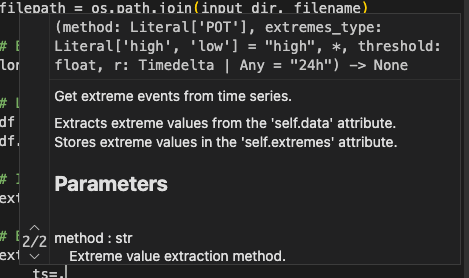

In [ ]:
# Process each CSV file
for filename in os.listdir(input_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(input_dir, filename)

        # Extract longitude and latitude from filename
        lon_lat = filename.replace('.csv', '')

        data = (
                pd
                .read_csv(filepath, index_col=0, parse_dates=True)
                .sort_index(ascending=True)
                .dropna()
                )

        data = data['Rainfall_mm'].astype(float).squeeze()

        # Initialize Extremes object with the time series
        model = EVA(data = data)

        threshold_data = float(np.percentile(data,98))

        # Extract peaks over threshold at 98% quantile
        model.get_extremes(
            method='POT',
            extremes_type='high',
            threshold=threshold_data,
            r="24h",
        )


        min_extremes_required = 2
        # Check if enough extremes for fitting
        if len(model.extremes) <= min_extremes_required:
          print(f"Not enough extremes extracted for {lon_lat}, skipping model fitting.")
          continue


        # Fit the GPD model to extracted extremes
        model.fit_model()

        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                # Extract only the first value (return level) from the tuple
                ret_level = ret_level_tuple[0]
                results_by_return_period[rp].append({
                    'longitude_latitude': lon_lat,
                    'return_level': ret_level
                })
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")



        # Get summary with return values and confidence intervals
        try:
            summary_df = model.get_summary(
                return_period=return_periods,
                return_period_size='365.2425D',
                alpha = 0.95
            )

            print(summary_df)

            # Reset index to make return_period a column
            summary_df = summary_df.reset_index().rename(columns={'index': 'return period'})
            # Add longitude_latitude column
            summary_df['longitude_latitude'] = lon_lat
            # Reorder columns
            summary_df = summary_df[['longitude_latitude', 'return period', 'return value', 'lower ci', 'upper ci']]
            # Save summary to CSV
            summary_output_path = os.path.join(output_dir, f'summary_{lon_lat}.csv')
            summary_df.to_csv(summary_output_path, index=False)
        except Exception as e:
            print(f"Failed to get summary for {lon_lat}: {e}")

'''
        # Initialize result dictionary for this grid point
        results[lon_lat] = {'longitude_latitude': lon_lat}

        # Estimate return levels
        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                ret_level = ret_level_tuple[0]
                results[lon_lat][f'return_level_{rp}years'] = ret_level
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")
                results[lon_lat][f'return_level_{rp}years'] = None



# Convert results to DataFrame
result_df = pd.DataFrame(list(results.values()))

# Save combined results to a single CSV
output_path = os.path.join(output_dir, 'return_levels_all_periods.csv')
result_df.to_csv(output_path, index=False)
'''

'''
        # Estimate return levels
        for rp in return_periods:
            try:
                ret_level_tuple = model.get_return_value(return_period=rp)
                ret_level = ret_level_tuple[0]
                results_by_return_period[rp].append({
                    'longitude_latitude': lon_lat,
                    'return_level': ret_level
                })
            except Exception as e:
                print(f"Failed for {filename} at {rp} years: {e}")

# Save results for each return period
for rp, results in results_by_return_period.items():
    result_df = pd.DataFrame(results)
    output_path = os.path.join(output_dir, f'return_level_{rp}years.csv')
    result_df.to_csv(output_path, index=False)'''

               return value    lower ci     upper ci
return period                                       
5.0              165.296893  163.597485   166.545192
6.0              179.428815  164.338670   188.583483
7.0              189.063977  165.078395   201.443625
8.0              196.008810  165.874337   209.560408
9.0              201.226215  166.727070   214.991311
...                     ...         ...          ...
996.0            233.340333  190.719793  3536.478753
997.0            233.340435  190.719801  3540.638606
998.0            233.340537  190.719810  3544.799404
999.0            233.340638  190.719818  3548.961146
1000.0           233.340739  190.719826  3553.123831

[996 rows x 3 columns]
               return value    lower ci     upper ci
return period                                       
5.0              293.434061  284.702988   293.434061
6.0              356.744979  288.306064   356.744979
7.0              390.664032  291.714617   390.664032
8.0              410.5

KeyboardInterrupt: 

In [ ]:
import os
import zipfile

# Define the results directory (where CSV files are stored)
results_dir = 'results'  # Replace with actual path to results folder

# Define the output path for the ZIP file
zip_output_path = os.path.join(results_dir, '000results_archive.zip')

# Create a ZIP file and add all CSV files from the results directory
with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir(results_dir):
        if filename.endswith('.csv'):
            file_path = os.path.join(results_dir, filename)
            # Add file to ZIP, using just the filename (not full path) in the archive
            zipf.write(file_path, os.path.basename(filename))

print(f"All CSV files in {results_dir} have been zipped into {zip_output_path}")

All CSV files in results have been zipped into results/000results_archive.zip


In [ ]:
def unzip_rainfall_data(zip_path, extract_path):
    extract_path = Path(extract_path)
    extract_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Unzipped rainfall data to {extract_path}")


In [ ]:
unzip_rainfall_data("000results_archive.zip", "results")

Unzipped rainfall data to results


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Data preview:
                        longitude_latitude  return period  return value  \
0  117.0505354196906893_7.9500363655407185            1.0          -inf   
1  117.0505354196906893_7.9500363655407185            2.0          -inf   
2  117.0505354196906893_7.9500363655407185            3.0          -inf   
3  117.0505354196906893_7.9500363655407185            4.0          -inf   
4  117.0505354196906893_7.9500363655407185            5.0    144.187019   

     lower ci    upper ci  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4  141.434962  146.083051  

Valid data for plotting:
                          longitude_latitude  return period  return value  \
4    117.0505354196906893_7.9500363655407185            5.0    144.187019   
5    117.0505354196906893_7.9500363655407185            6.0    164.745309   
6    117.0505354196906893_7.9500363655407185            7.0    176.326959   
7    117.0505354196906893_7.95003

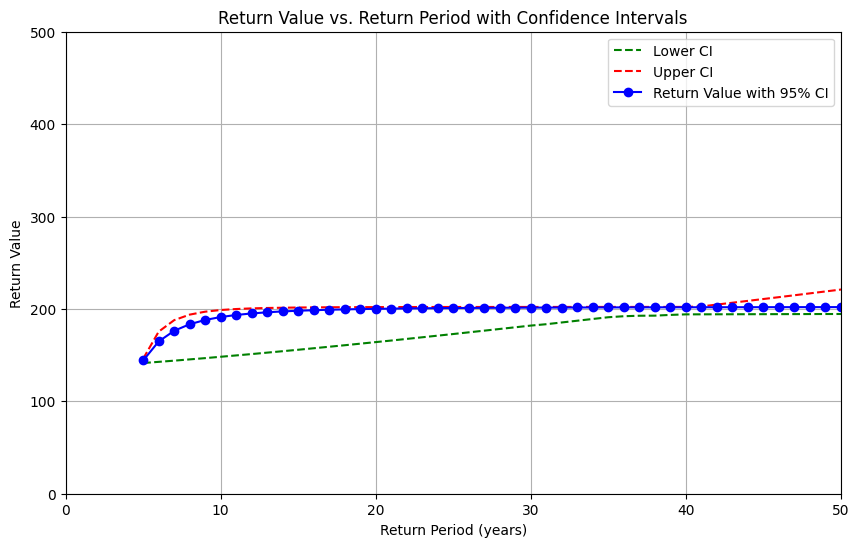

In [ ]:
import pandas as pd
import numpy as np

# File name
file_path = 'results/summary_117.0505354196906893_7.9500363655407185.csv'

try:
    # Read the CSV file
    df = pd.read_csv(file_path)

    # Display the first few rows to verify the data
    print("Data preview:")
    print(df.head())

    # Replace '-inf' with NaN for easier handling
    df.replace(-float('inf'), np.nan, inplace=True)

    # Ensure relevant columns exist
    expected_columns = ['return period', 'return value', 'lower ci', 'upper ci']
    if not all(col in df.columns for col in expected_columns):
        print("Error: CSV file does not contain all expected columns:", expected_columns)
    else:
        # Filter out rows with NaN in 'return value' for plotting
        valid_data = df.dropna(subset=['return value'])

        # Extract data for plotting
        return_periods = valid_data['return period']
        return_values = valid_data['return value']
        lower_ci = valid_data['lower ci']
        upper_ci = valid_data['upper ci']

        print("\nValid data for plotting:")
        print(valid_data)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_path}' is empty.")
except Exception as e:
    print(f"Error reading the file: {e}")


# Create the plot
plt.figure(figsize=(10, 6))
plt.errorbar(return_periods, return_values, fmt='-o', capsize=5,
             label='Return Value with 95% CI', color='blue', ecolor='gray')
# Plot lower CI line
plt.plot(return_periods, lower_ci, '--', color='green', label='Lower CI')
# Plot upper CI line
plt.plot(return_periods, upper_ci, '--', color='red', label='Upper CI')

plt.xscale('linear')  # Linear scale for clarity; log scale could be used if requested
plt.xlabel('Return Period (years)')
plt.ylabel('Return Value')
plt.title('Return Value vs. Return Period with Confidence Intervals')
plt.xlim(0, 50)  # Set x-axis to 0-1000 years as requested
plt.ylim(0, 500)
plt.grid(True)
plt.legend()

# Show the plot
plt.show()